# 2.3 
# Метод простой итерации

## Упражнение №1:
### Проилюстрируйте графически сходящийся итерационный процесс при условии, что: -1 < f'(x) < 0 на отрезке [a; b]

In [1]:
from numpy import *
import matplotlib.pyplot as plt
from tabulate import tabulate

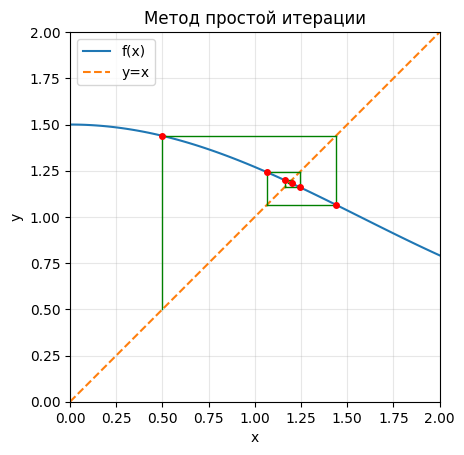

Итерации:
+-----+----------+
|   n |      x_n |
+=====+==========+
|   0 | 0.500000 |
+-----+----------+
|   1 | 1.438791 |
+-----+----------+
|   2 | 1.065811 |
+-----+----------+
|   3 | 1.241897 |
+-----+----------+
|   4 | 1.161501 |
+-----+----------+
|   5 | 1.198982 |
+-----+----------+
|   6 | 1.181653 |
+-----+----------+


In [2]:
f = lambda x: 0.5 * cos(x) + 1

x = linspace(0, 2, 100)
plt.plot(x, f(x), label='f(x)')
plt.plot(x, x, label='y=x', linestyle='--')
plt.grid(True, alpha=0.3)

x0 = 0.5
x_points = [x0]

for i in range(6):
    # использование lambda f
    next_val = f(x_points[-1])
    x_points.append(next_val)
    
    plt.plot([x_points[i], x_points[i]], [x_points[i], x_points[i+1]], 'g-', linewidth=1)
    plt.plot([x_points[i], x_points[i+1]], [x_points[i+1], x_points[i+1]], 'g-', linewidth=1)
    plt.plot(x_points[i], f(x_points[i]), 'ro', markersize=4)

plt.title('Метод простой итерации')
plt.xlabel('x'), plt.ylabel('y')
plt.legend(), plt.axis([0, 2, 0, 2]), plt.gca().set_aspect('equal')
plt.show()

table_data = [[i, val] for i, val in enumerate(x_points)]
print("Итерации:")
print(tabulate(table_data, headers=['n', 'x_n'], tablefmt='grid', floatfmt=(".0f", ".6f")))

## Упражнение №2:
### Уточнить наименьший по модулю отличный от нуля корень уравнения x - sin(x) - 1 = 0 методом простой итерации с точностью до 10^-5

In [3]:
fi = lambda x: x - 0.5 * (x * sin(x) - 1)

x = 1.1
rows = []
eps = 10**-5

# Основной цикл вычислений
for n in range(1, 20):
    x_new = fi(x)
    diff = abs(x_new - x)
    
    # Собираем данные для таблицы
    rows.append([n, x_new, diff])
    
    if diff < eps:
        break
    x = x_new

headers = ["n", "x_n", "|x_n - x_n-1|"]
print(tabulate(rows, headers=headers, tablefmt="grid", floatfmt=(".0f", ".8f", ".8f")))

root = rows[-1][1]
check_val = root * sin(root) - 1
print(f"\nКорень: x = {root:.8f}")
print(f"Проверка: f(x) = {check_val:.2e}")

+-----+------------+-----------------+
|   n |        x_n |   |x_n - x_n-1| |
+=====+============+=================+
|   1 | 1.10983595 |      0.00983595 |
+-----+------------+-----------------+
|   2 | 1.11283714 |      0.00300118 |
+-----+------------+-----------------+
|   3 | 1.11375380 |      0.00091667 |
+-----+------------+-----------------+
|   4 | 1.11403389 |      0.00028008 |
+-----+------------+-----------------+
|   5 | 1.11411948 |      0.00008559 |
+-----+------------+-----------------+
|   6 | 1.11414563 |      0.00002615 |
+-----+------------+-----------------+
|   7 | 1.11415362 |      0.00000799 |
+-----+------------+-----------------+

Корень: x = 1.11415362
Проверка: f(x) = -4.89e-06
